# Fashion-MNIST Classification and Model Comparison

### PCA-Based Dimensionality Reduction with Classical Model Benchmarking

This notebook presents a comparative evaluation of Gaussian Naive Bayes and Logistic Regression on the Fashion-MNIST dataset using flat-pixel input features.


## Objectives

- Use `FMNIST_TRAIN.csv` for training and `FMNIST_TEST.csv` for testing
- Apply preprocessing and PCA-based dimensionality reduction
- Train and tune Gaussian Naive Bayes and Logistic Regression models
- Compare performance using standard classification metrics
- Provide visual analysis of class patterns and model behavior


In [1]:
# Core imports
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    top_k_accuracy_score,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

warnings.filterwarnings("ignore")


## Dataset Loading

This notebook uses flat-pixel CSV inputs only:

- `FMNIST_TRAIN.csv` (or `fashion-mnist_train.csv`)
- `FMNIST_TEST.csv` (or `fashion-mnist_test.csv`)

Recommended before training:

```bash
python preprocess_fmnist.py
```

If `processed/fmnist_preprocessed.npz` exists, it is loaded directly. Otherwise CSV files are parsed.


In [2]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

TRAIN_CSV = Path("FMNIST_TRAIN.csv")
TEST_CSV = Path("FMNIST_TEST.csv")
TRAIN_CSV_FALLBACK = Path("fashion-mnist_train.csv")
TEST_CSV_FALLBACK = Path("fashion-mnist_test.csv")
PREPROCESSED_NPZ = Path("processed") / "fmnist_preprocessed.npz"
LABEL_CANDIDATES = ["label", "Label", "Class", "target", "Target", "y", "Y"]
PIXELS_CANDIDATES = ["pixels", "Pixels", "pixel_values", "Pixel_Values"]


def _resolve_csv_paths(train_csv: Path, test_csv: Path):
    if train_csv.exists() and test_csv.exists():
        return train_csv, test_csv
    if TRAIN_CSV_FALLBACK.exists() and TEST_CSV_FALLBACK.exists():
        return TRAIN_CSV_FALLBACK, TEST_CSV_FALLBACK
    raise FileNotFoundError(
        "Could not find dataset CSVs. Expected FMNIST_TRAIN.csv/FMNIST_TEST.csv or "
        "fashion-mnist_train.csv/fashion-mnist_test.csv in project root."
    )


def _load_flat_pixel_csv(df: pd.DataFrame, split_name: str):
    label_col = next((c for c in LABEL_CANDIDATES if c in df.columns), None)
    if label_col is None and df.shape[1] == 785:
        label_col = df.columns[0]

    if label_col is None:
        raise ValueError(f"{split_name}: unable to infer label column")

    y = df[label_col].astype(int).to_numpy()

    pixels_col = next((c for c in PIXELS_CANDIDATES if c in df.columns), None)
    if pixels_col is not None:
        pixel_rows = (
            df[pixels_col]
            .astype(str)
            .str.replace(",", " ", regex=False)
            .str.split()
            .map(lambda row: [int(v) for v in row])
        )
        x = np.asarray(pixel_rows.tolist(), dtype=np.uint8)
    else:
        candidate_cols = [c for c in df.columns if c != label_col]
        drop_noise = {"Unnamed: 0", "id", "ID", "Image_File", "image_file", "filename", "file_name"}
        candidate_cols = [c for c in candidate_cols if c not in drop_noise]

        numeric_cols = []
        for col in candidate_cols:
            series = pd.to_numeric(df[col], errors="coerce")
            if series.notna().all():
                numeric_cols.append(col)

        x = df[numeric_cols].to_numpy(dtype=np.float32)

    if x.shape[1] != 784:
        raise ValueError(f"{split_name}: expected 784 pixel values, found {x.shape[1]}")

    x = np.clip(x, 0, 255).reshape(-1, 28, 28).astype(np.uint8)
    return x, y


def _load_from_required_csv(train_csv: Path = TRAIN_CSV, test_csv: Path = TEST_CSV):
    train_csv, test_csv = _resolve_csv_paths(train_csv, test_csv)
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)

    x_train, y_train = _load_flat_pixel_csv(train_df, "train")
    x_test, y_test = _load_flat_pixel_csv(test_df, "test")
    source = f"{train_csv.name} + {test_csv.name}"
    return x_train, y_train, x_test, y_test, source


def load_fmnist_dataset():
    if PREPROCESSED_NPZ.exists():
        data = np.load(PREPROCESSED_NPZ)
        required = {"x_train", "y_train", "x_test", "y_test"}
        if required.issubset(set(data.files)):
            return (
                data["x_train"].astype(np.uint8),
                data["y_train"].astype(int),
                data["x_test"].astype(np.uint8),
                data["y_test"].astype(int),
                f"preprocessed bundle ({PREPROCESSED_NPZ})",
            )

    return _load_from_required_csv(TRAIN_CSV, TEST_CSV)


x_train_img, y_train, x_test_img, y_test, data_source = load_fmnist_dataset()
print(f"Loaded from: {data_source}")
print(f"Train shape: {x_train_img.shape}, Test shape: {x_test_img.shape}")


Loaded from: preprocessed bundle (processed\fmnist_preprocessed.npz)
Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)


## Quick EDA: Class Balance + Pixel Statistics

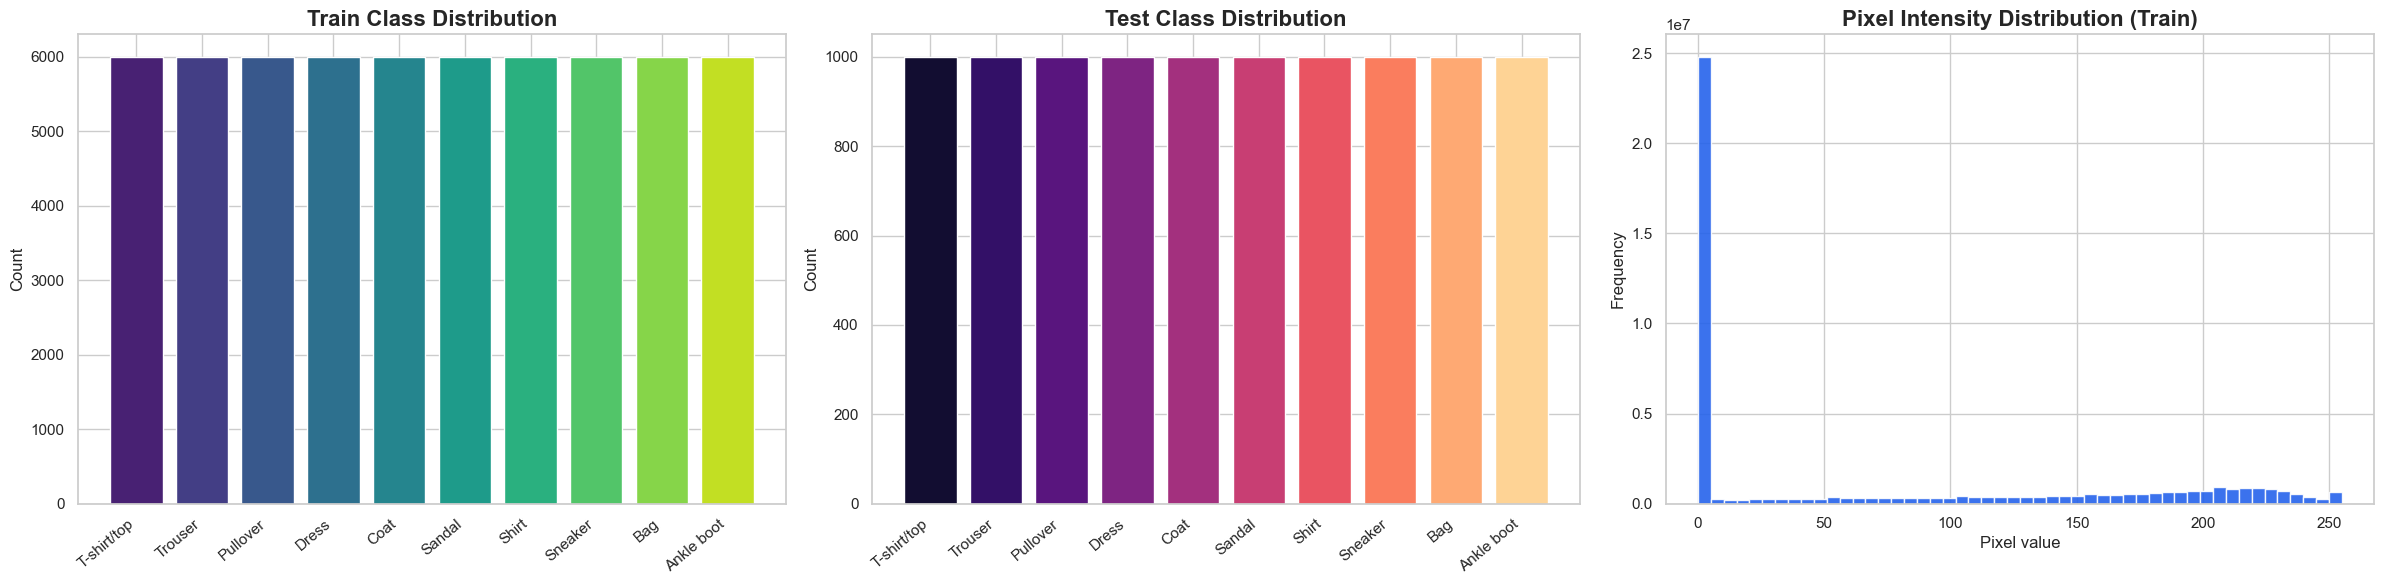

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Class balance (train)
train_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(range(10), train_counts.values, color=sns.color_palette("viridis", 10))
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(CLASS_NAMES, rotation=40, ha="right")
axes[0].set_title("Train Class Distribution")
axes[0].set_ylabel("Count")

# Class balance (test)
test_counts = pd.Series(y_test).value_counts().sort_index()
axes[1].bar(range(10), test_counts.values, color=sns.color_palette("magma", 10))
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(CLASS_NAMES, rotation=40, ha="right")
axes[1].set_title("Test Class Distribution")
axes[1].set_ylabel("Count")

# Pixel histogram
axes[2].hist(x_train_img.ravel(), bins=50, color="#2563eb", alpha=0.9)
axes[2].set_title("Pixel Intensity Distribution (Train)")
axes[2].set_xlabel("Pixel value")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

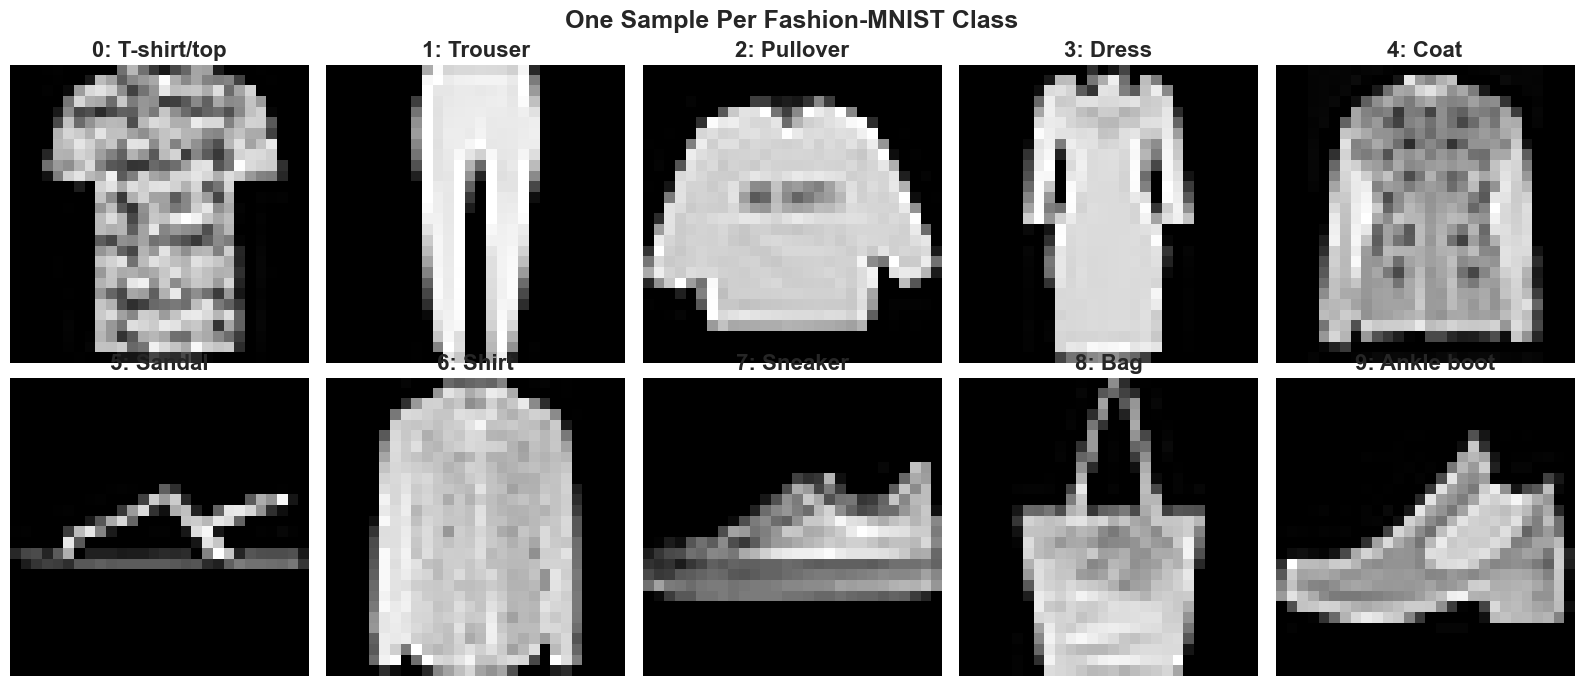

In [4]:
# Show example images per class
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for class_id in range(10):
    idx = np.where(y_train == class_id)[0][0]
    ax = axes[class_id // 5, class_id % 5]
    ax.imshow(x_train_img[idx], cmap="gray")
    ax.set_title(f"{class_id}: {CLASS_NAMES[class_id]}")
    ax.axis("off")

plt.suptitle("One Sample Per Fashion-MNIST Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

## Preprocessing

- Flatten 28x28 images to 784-dimensional vectors
- Normalize pixel values to [0, 1]
- Keep an internal train/validation split for model tuning

In [5]:
# Flatten + normalize
x_train = x_train_img.reshape(len(x_train_img), -1).astype(np.float32) / 255.0
x_test = x_test_img.reshape(len(x_test_img), -1).astype(np.float32) / 255.0

x_fit, x_val, y_fit, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train,
)

print(f"x_fit:  {x_fit.shape}")
print(f"x_val:  {x_val.shape}")
print(f"x_test: {x_test.shape}")

x_fit:  (51000, 784)
x_val:  (9000, 784)
x_test: (10000, 784)


## PCA Exploration

Before final modeling, we inspect PCA behavior:
- Explained variance curve
- 2D projection (subset)
- Reconstruction quality

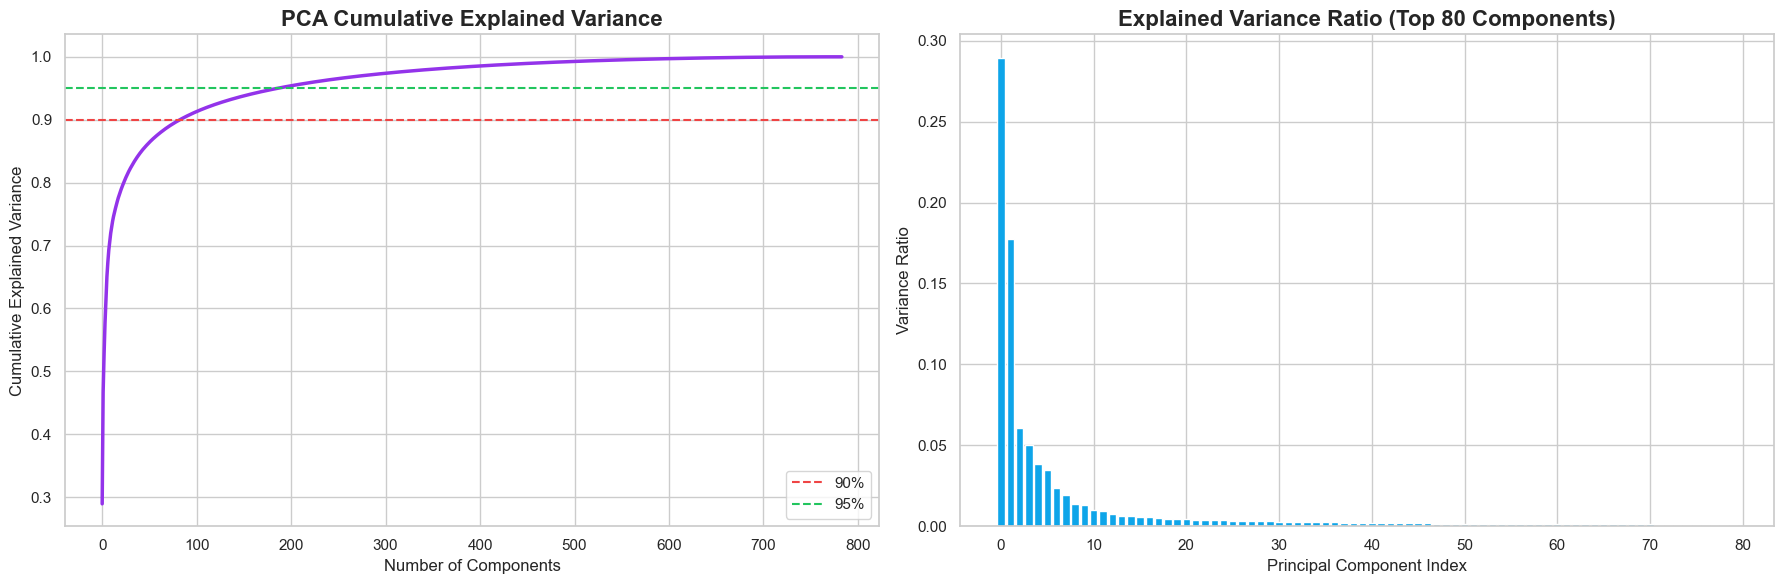

Components for >=90% variance: 84
Components for >=95% variance: 187


In [6]:
# Fit PCA once to inspect explained variance
pca_probe = PCA(n_components=None, svd_solver="randomized", random_state=SEED)
pca_probe.fit(x_fit)

cum_exp_var = np.cumsum(pca_probe.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Cumulative explained variance
axes[0].plot(cum_exp_var, color="#9333ea", linewidth=2.5)
axes[0].axhline(0.90, linestyle="--", color="#ef4444", label="90%")
axes[0].axhline(0.95, linestyle="--", color="#22c55e", label="95%")
axes[0].set_title("PCA Cumulative Explained Variance")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].legend()

# First 80 components scree style
top_k = 80
axes[1].bar(np.arange(top_k), pca_probe.explained_variance_ratio_[:top_k], color="#0ea5e9")
axes[1].set_title("Explained Variance Ratio (Top 80 Components)")
axes[1].set_xlabel("Principal Component Index")
axes[1].set_ylabel("Variance Ratio")

plt.tight_layout()
plt.show()

components_90 = int(np.argmax(cum_exp_var >= 0.90) + 1)
components_95 = int(np.argmax(cum_exp_var >= 0.95) + 1)
print(f"Components for >=90% variance: {components_90}")
print(f"Components for >=95% variance: {components_95}")

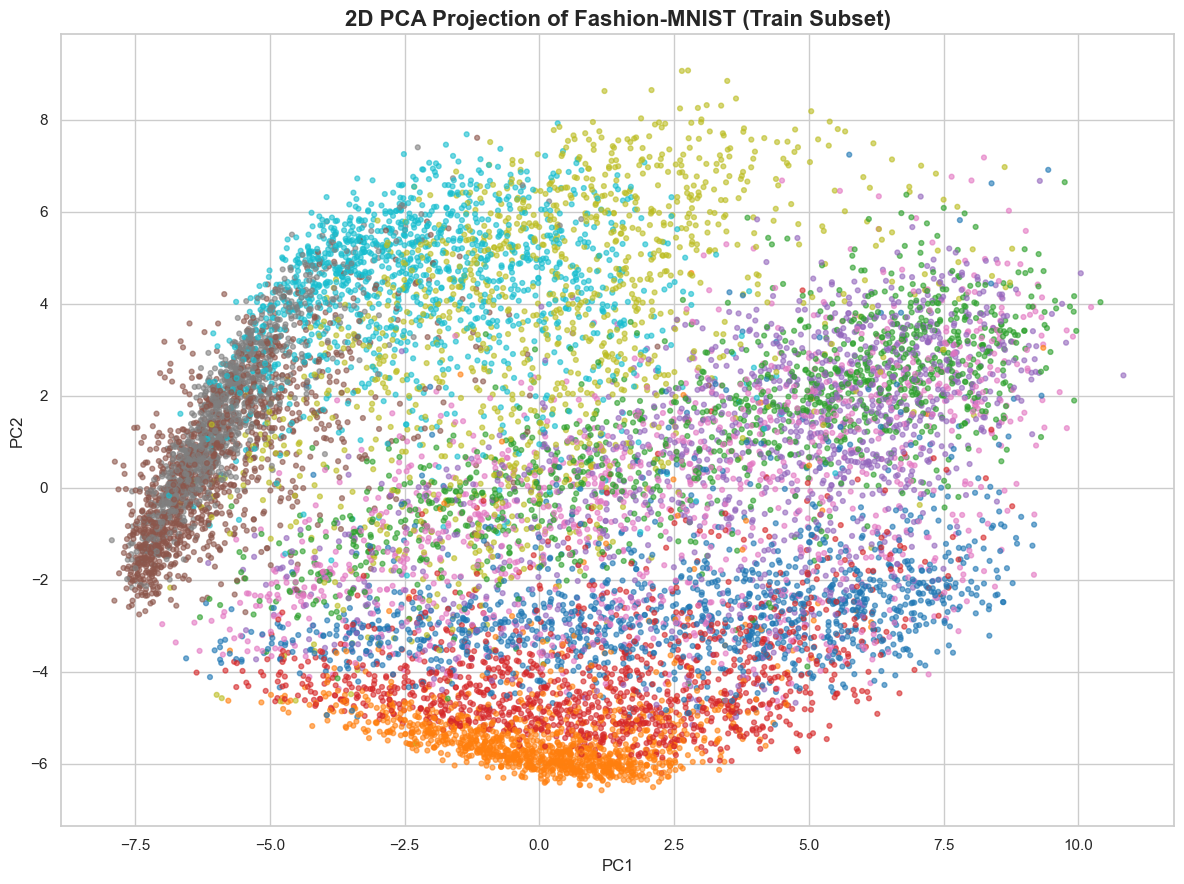

In [7]:
# 2D PCA projection (subset for speed + visualization clarity)
subset_n = min(12000, len(x_fit))
subset_idx = np.random.choice(len(x_fit), size=subset_n, replace=False)

pca_2d = PCA(n_components=2, random_state=SEED)
x_2d = pca_2d.fit_transform(x_fit[subset_idx])
y_2d = y_fit[subset_idx]

plt.figure(figsize=(12, 9))
scatter = plt.scatter(
    x_2d[:, 0], x_2d[:, 1],
    c=y_2d, cmap="tab10", s=12, alpha=0.6
)
plt.title("2D PCA Projection of Fashion-MNIST (Train Subset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
legend = plt.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend)
plt.tight_layout()
plt.show()

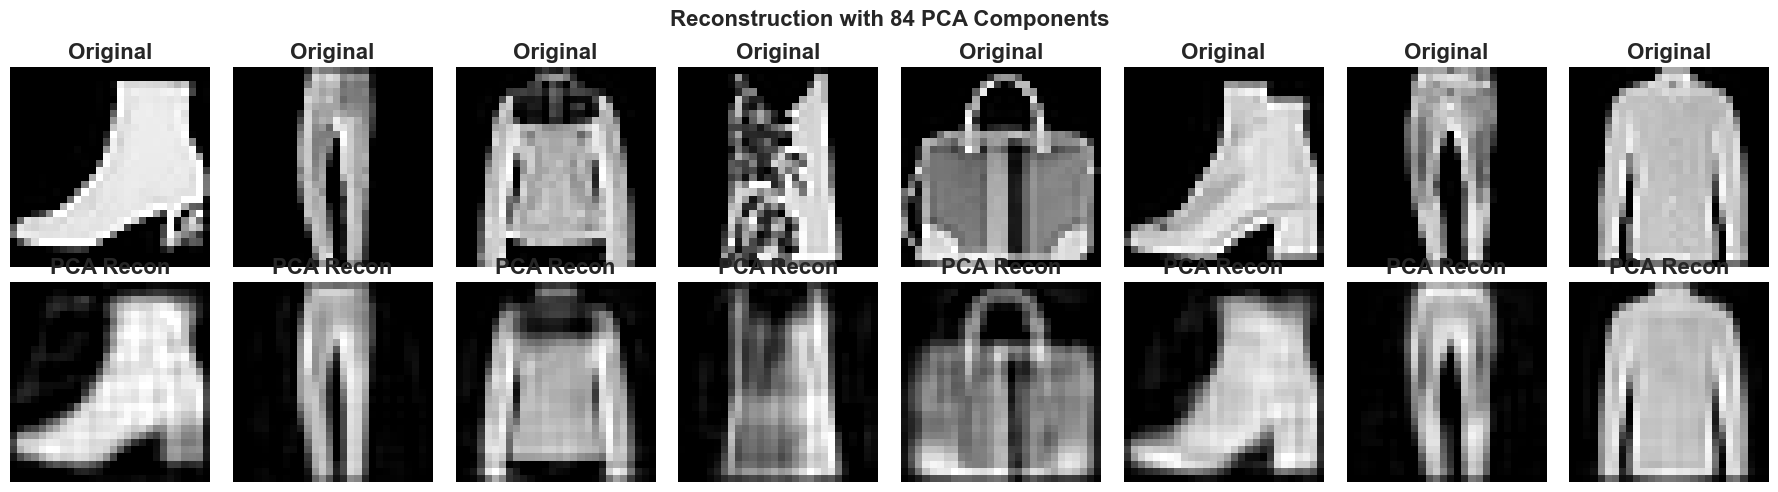

In [8]:
# Reconstruction quality for a few samples
n_components_recon = max(60, components_90)
pca_recon = PCA(n_components=n_components_recon, svd_solver="randomized", random_state=SEED)
x_fit_reduced = pca_recon.fit_transform(x_fit)
x_fit_reconstructed = pca_recon.inverse_transform(x_fit_reduced)

sample_ids = np.random.choice(len(x_fit), size=8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, idx in enumerate(sample_ids):
    axes[0, i].imshow(x_fit[idx].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(np.clip(x_fit_reconstructed[idx].reshape(28, 28), 0, 1), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("PCA Recon")

plt.suptitle(f"Reconstruction with {n_components_recon} PCA Components", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Model Training: Naive Bayes vs Logistic Regression

We train and compare:
- **Gaussian Naive Bayes** on PCA features
- **Multinomial Logistic Regression** in a pipeline with StandardScaler + PCA

Both are tuned with cross-validation.

In [9]:
results = {}
artifacts = {}


def evaluate_model(model_name, y_true, y_pred, y_proba, classes):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    top3 = top_k_accuracy_score(y_true, y_proba, k=3, labels=classes) if y_proba is not None else np.nan

    return {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "top3_accuracy": top3,
    }


# ---------- Naive Bayes ----------
print("Training GaussianNB with PCA tuning...")
nb_pipeline = Pipeline([
    ("pca", PCA(svd_solver="randomized", random_state=SEED)),
    ("nb", GaussianNB()),
])

nb_param_grid = {
    "pca__n_components": [40, 60, 80, 100, 120, max(components_90, 80)],
    "nb__var_smoothing": np.logspace(-11, -7, 7),
}

nb_search = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

start = time.perf_counter()
nb_search.fit(x_fit, y_fit)
nb_train_time = time.perf_counter() - start

nb_best = nb_search.best_estimator_
nb_pred = nb_best.predict(x_test)
nb_proba = nb_best.predict_proba(x_test)

results["GaussianNB + PCA"] = evaluate_model(
    "GaussianNB + PCA", y_test, nb_pred, nb_proba, classes=np.arange(10)
)
results["GaussianNB + PCA"]["train_time_sec"] = nb_train_time

artifacts["GaussianNB + PCA"] = {
    "estimator": nb_best,
    "y_pred": nb_pred,
    "y_proba": nb_proba,
    "best_params": nb_search.best_params_,
}

print(f"Best NB params: {nb_search.best_params_}")
print(f"NB training time: {nb_train_time:.2f} sec")


# ---------- Logistic Regression ----------
print("\nTraining Logistic Regression pipeline with PCA tuning...")
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(svd_solver="randomized", random_state=SEED)),
    (
        "lr",
        LogisticRegression(
            solver="lbfgs",
            max_iter=3000,
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
])

lr_param_grid = {
    "pca__n_components": [80, 100, 120, 150, 180, 220],
    "lr__C": np.logspace(-2, 1.3, 10),
}

lr_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

start = time.perf_counter()
lr_search.fit(x_fit, y_fit)
lr_train_time = time.perf_counter() - start

lr_best = lr_search.best_estimator_
lr_pred = lr_best.predict(x_test)
lr_proba = lr_best.predict_proba(x_test)

results["LogisticRegression + StandardScaler + PCA"] = evaluate_model(
    "LogisticRegression + StandardScaler + PCA",
    y_test,
    lr_pred,
    lr_proba,
    classes=np.arange(10),
)
results["LogisticRegression + StandardScaler + PCA"]["train_time_sec"] = lr_train_time

artifacts["LogisticRegression + StandardScaler + PCA"] = {
    "estimator": lr_best,
    "y_pred": lr_pred,
    "y_proba": lr_proba,
    "best_params": lr_search.best_params_,
}

print(f"Best LR params: {lr_search.best_params_}")
print(f"LR training time: {lr_train_time:.2f} sec")

Training GaussianNB with PCA tuning...
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best NB params: {'nb__var_smoothing': np.float64(1e-11), 'pca__n_components': 60}
NB training time: 36.16 sec

Training Logistic Regression pipeline with PCA tuning...
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best LR params: {'lr__C': np.float64(0.054116952654646375), 'pca__n_components': 220}
LR training time: 1245.55 sec


## Metrics and Comparison Table

In [10]:
metrics_df = pd.DataFrame(results.values()).sort_values("accuracy", ascending=False).reset_index(drop=True)

# Pretty display
metrics_display = metrics_df.copy()
for col in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "top3_accuracy"]:
    metrics_display[col] = (metrics_display[col] * 100).map(lambda x: f"{x:.2f}%")
metrics_display["train_time_sec"] = metrics_df["train_time_sec"].map(lambda x: f"{x:.2f}")

print("Model Performance (sorted by Accuracy):")
display(metrics_display)

best_model_name = metrics_df.iloc[0]["model"]
print(f"\nBest model: {best_model_name}")
print("Best params:", artifacts[best_model_name]["best_params"])

Model Performance (sorted by Accuracy):


,model,accuracy,precision_macro,recall_macro,f1_macro,top3_accuracy,train_time_sec
0,LogisticRegression + StandardScaler + PCA,85.95%,85.80%,85.95%,85.86%,98.28%,1245.55
1,GaussianNB + PCA,78.27%,78.43%,78.27%,78.24%,95.34%,36.16



Best model: LogisticRegression + StandardScaler + PCA
Best params: {'lr__C': np.float64(0.054116952654646375), 'pca__n_components': 220}


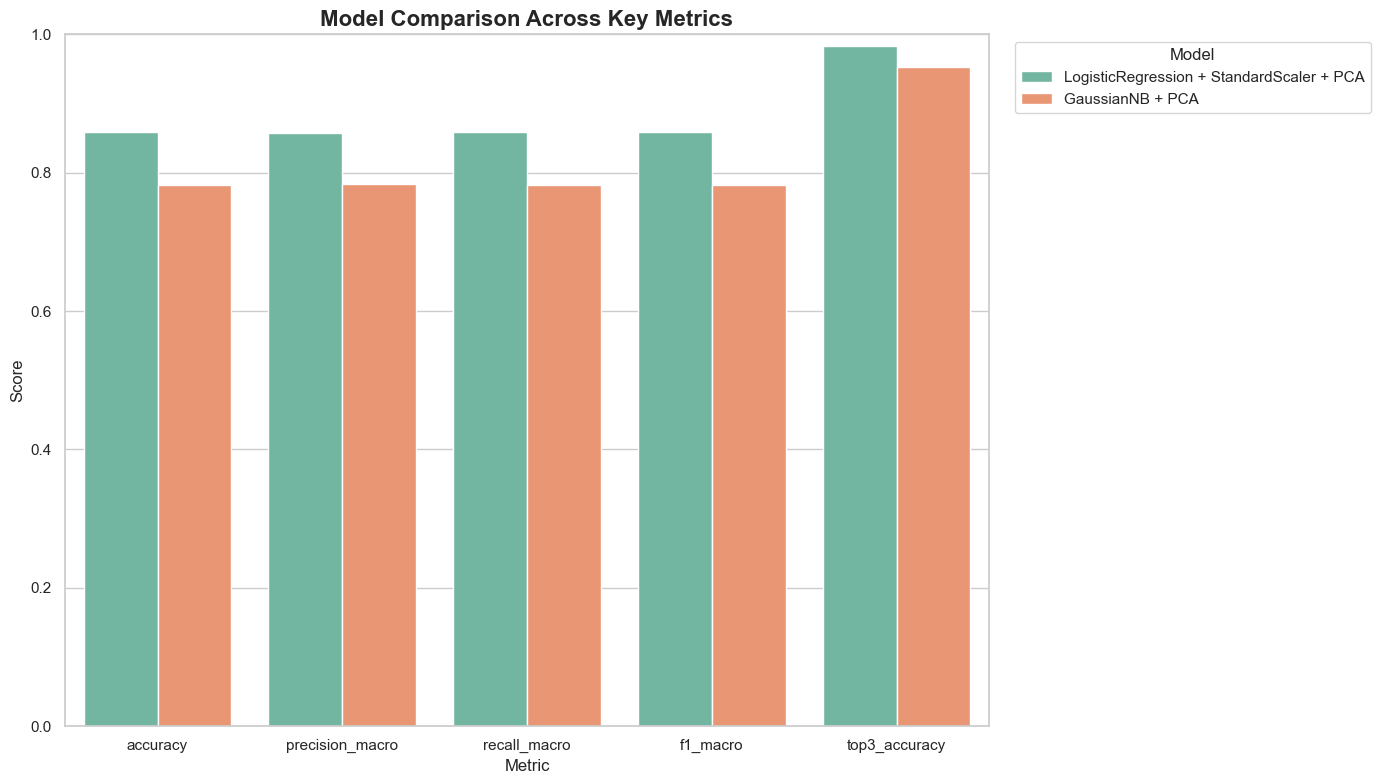

In [11]:
# Metric comparison chart
plot_df = metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision_macro", "recall_macro", "f1_macro", "top3_accuracy"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", palette="Set2")
plt.title("Model Comparison Across Key Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Confusion Matrices + Per-Class F1

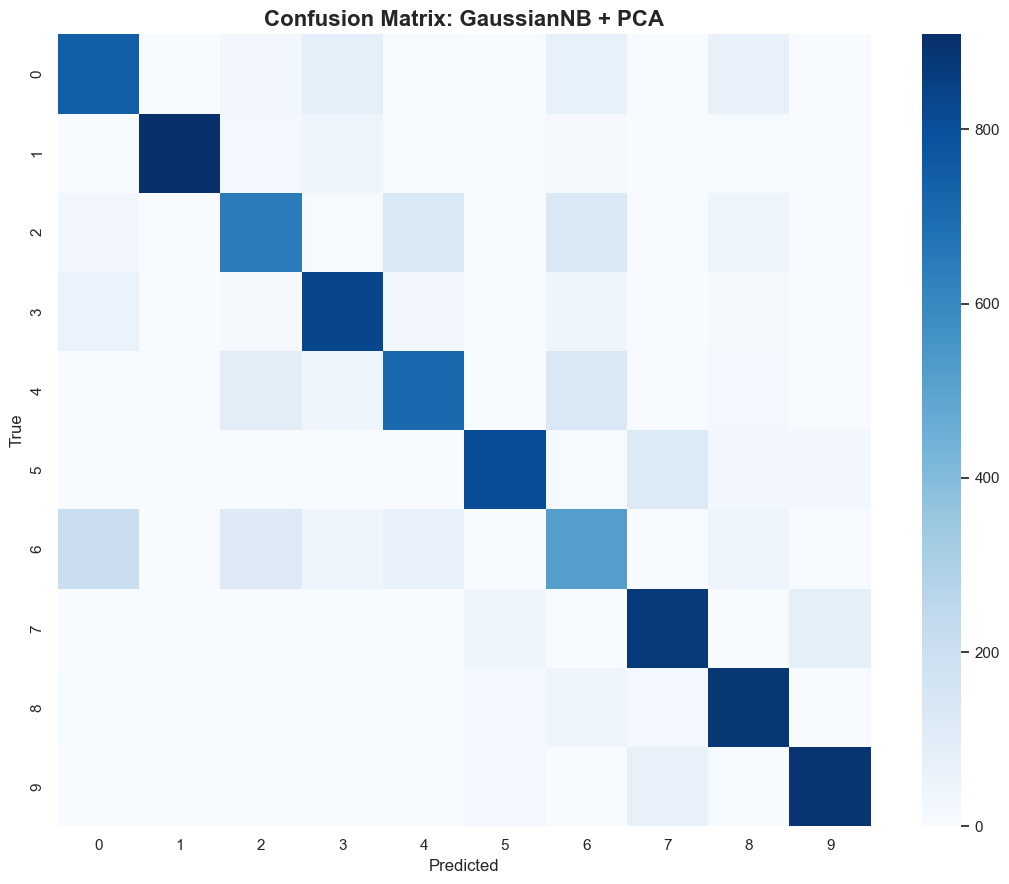

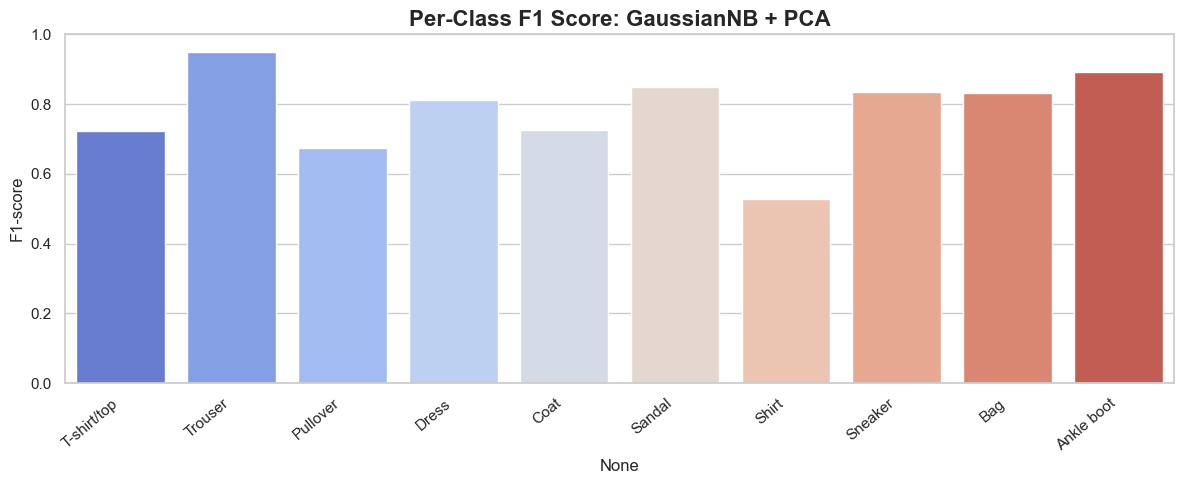

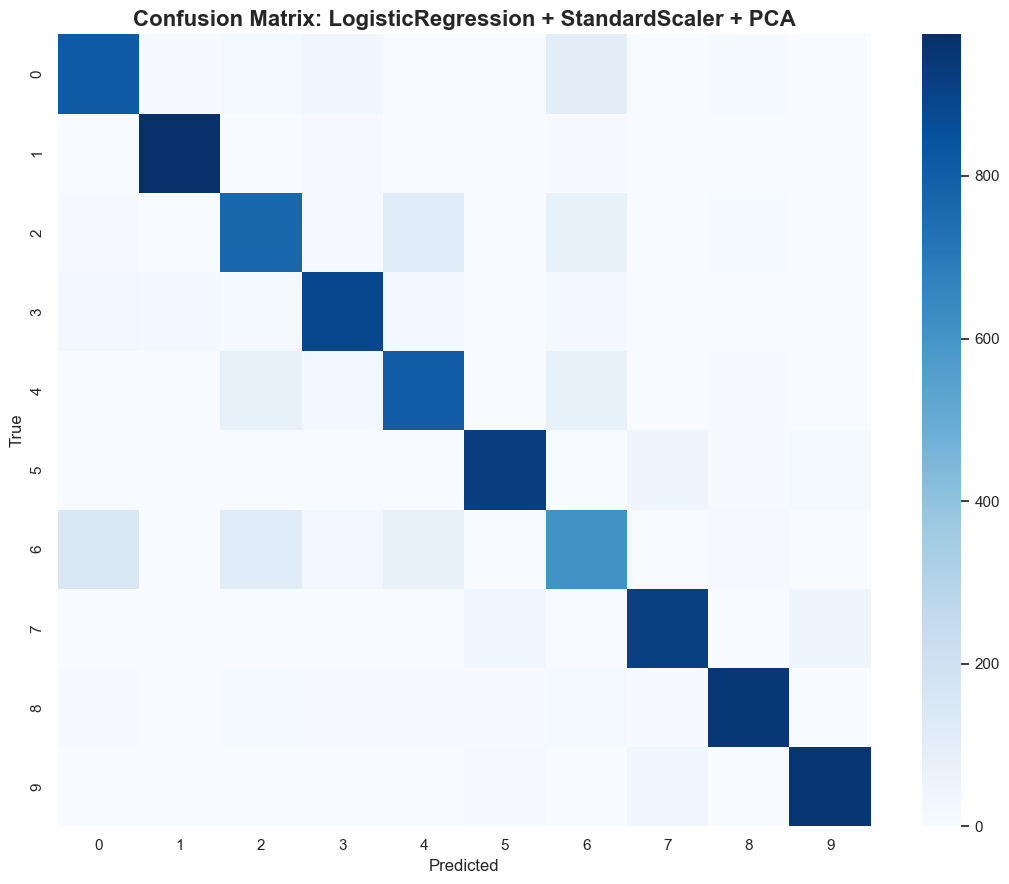

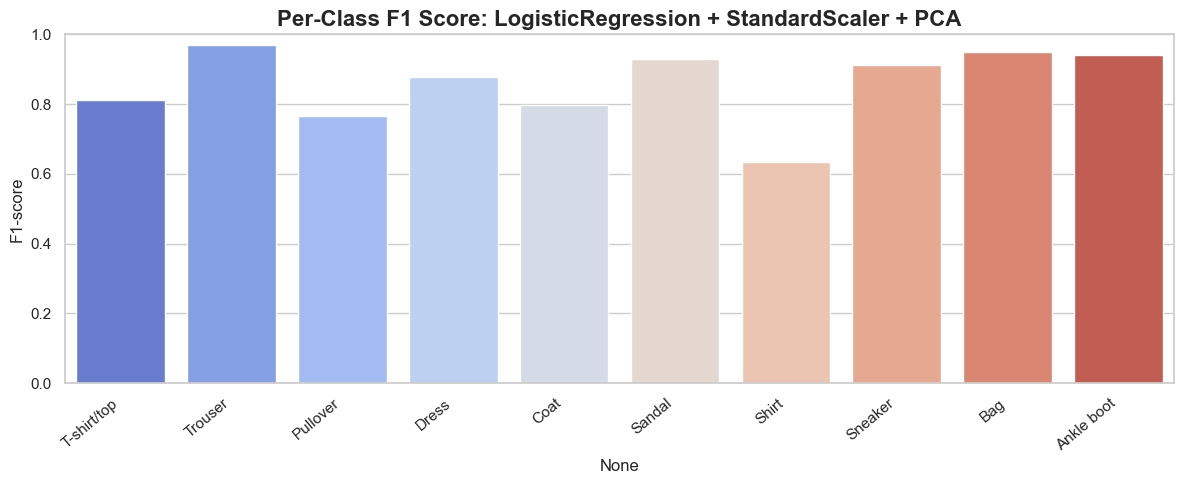

In [12]:
for model_name, obj in artifacts.items():
    y_pred = obj["y_pred"]

    cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=True)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    report = classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    per_class_f1 = pd.Series({k: v["f1-score"] for k, v in report.items() if k in CLASS_NAMES})

    plt.figure(figsize=(12, 5))
    sns.barplot(x=per_class_f1.index, y=per_class_f1.values, palette="coolwarm")
    plt.xticks(rotation=40, ha="right")
    plt.ylim(0, 1)
    plt.title(f"Per-Class F1 Score: {model_name}")
    plt.ylabel("F1-score")
    plt.tight_layout()
    plt.show()

## ROC Curves (One-vs-Rest)

We plot ROC curves for each class for the **best model**.

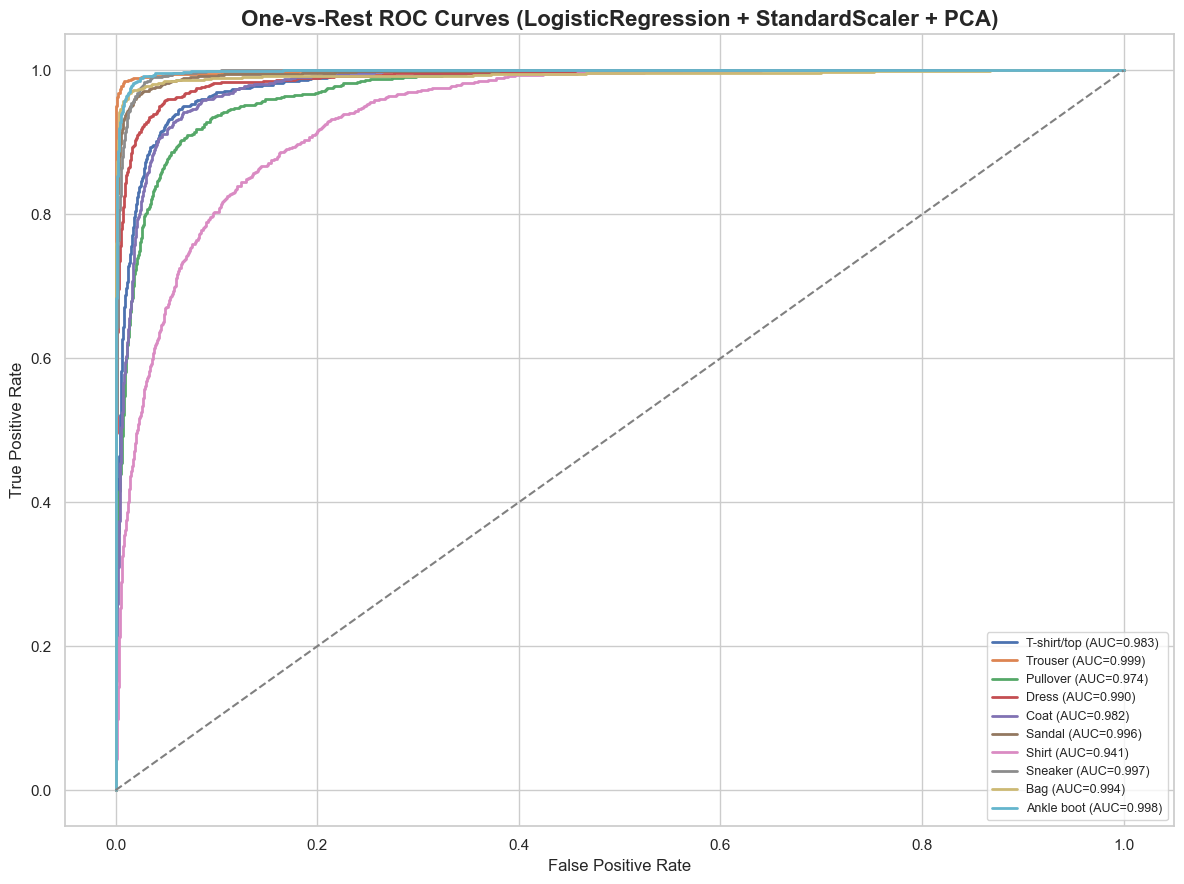

In [13]:
best_proba = artifacts[best_model_name]["y_proba"]
y_test_bin = label_binarize(y_test, classes=np.arange(10))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], best_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(12, 9))
for i in range(10):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{CLASS_NAMES[i]} (AUC={roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title(f"One-vs-Rest ROC Curves ({best_model_name})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Save Artifacts (metrics + results)

In [14]:
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Save metrics CSV
metrics_df.to_csv(output_dir / "metrics_summary.csv", index=False)

# Save JSON payload with metrics and best params
summary_payload = {
    "data_source": data_source,
    "best_model": best_model_name,
    "models": {},
}

for model_name, row in metrics_df.set_index("model").iterrows():
    summary_payload["models"][model_name] = {
        "accuracy": float(row["accuracy"]),
        "precision_macro": float(row["precision_macro"]),
        "recall_macro": float(row["recall_macro"]),
        "f1_macro": float(row["f1_macro"]),
        "top3_accuracy": float(row["top3_accuracy"]),
        "train_time_sec": float(row["train_time_sec"]),
        "best_params": artifacts[model_name]["best_params"],
    }

with (output_dir / "run_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("Saved:")
print("-", output_dir / "metrics_summary.csv")
print("-", output_dir / "run_summary.json")

Saved:
- outputs\metrics_summary.csv
- outputs\run_summary.json


## Notes

- The analysis is constrained to PCA with Gaussian Naive Bayes and Logistic Regression.
- Exported metrics are saved in `outputs/metrics_summary.csv` and `outputs/run_summary.json`.
